Use the dataset given to you to forecast the sales demand in 20 weeks and in 6 months using the Simple Moving Average Model.


A) reveal and help understand the data
b) do the initial visualizations 
c) build the model
d) present my forecast for 6 months period
e) perform three performance metrics on the model
f) visualize the actual or the original data   and the forecast together



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
baba= pd.read_csv("SalesD.csv")

In [3]:
baba.head(15)

,Week,Date,Demand
0,1,01/01/2001,98.42
1,2,08/01/2001,122.81
2,3,15/01/2001,100.69
3,4,22/01/2001,100.54
4,5,29/01/2001,114.69
5,6,05/02/2001,105.05
6,7,12/02/2001,102.32
7,8,19/02/2001,118.37
8,9,26/02/2001,112.79
9,10,05/03/2001,115.21


In [4]:
baba.describe()

,Week,Demand
count,1331.000000,1331.000000
mean,666.000000,166.977979
std,384.370915,40.848164
min,1.000000,74.260000
25%,333.500000,133.975000
50%,666.000000,166.640000
75%,998.500000,199.770000
max,1331.000000,256.180000


In [5]:
baba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1331 entries, 0 to 1330
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Week    1331 non-null   int64  
 1   Date    1331 non-null   object 
 2   Demand  1331 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 31.3+ KB


In [6]:
baba.columns

Index(['Week', 'Date', 'Demand'], dtype='object')

In [7]:
baba.dtypes['Week']

dtype('int64')

In [8]:
baba.dtypes['Date']

dtype('O')

In [9]:
baba.dtypes['Demand']

dtype('float64')

In [10]:
baba.isna().sum()

Week      0
Date      0
Demand    0
dtype: int64

In [11]:
baba.duplicated().sum()

np.int64(0)

<Figure size 1500x1000 with 0 Axes>

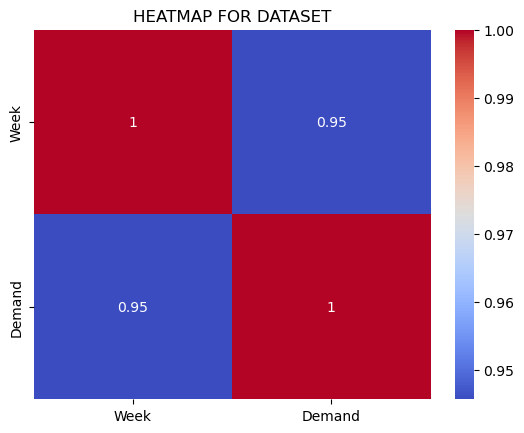

<Figure size 1500x1000 with 0 Axes>

In [12]:
corr=baba.corr(numeric_only=True)
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.title("HEATMAP FOR DATASET")
plt.figure(figsize=(15,10))


<Axes: ylabel='Density'>

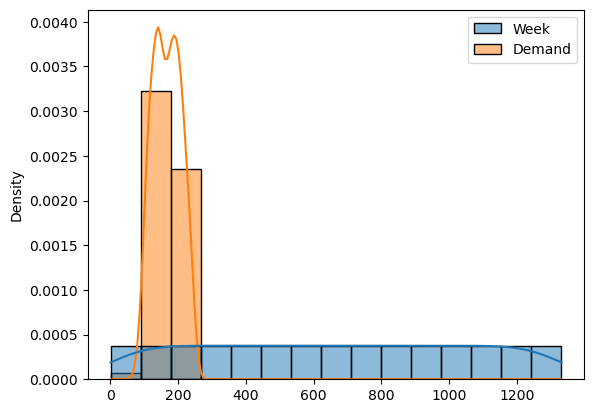

In [13]:
sns.histplot(baba,kde=True,color="royalblue",stat= "density",bins=15)
### week is normally distributed, nothing was changing it if we dont have mistakes with the dates in the dataset

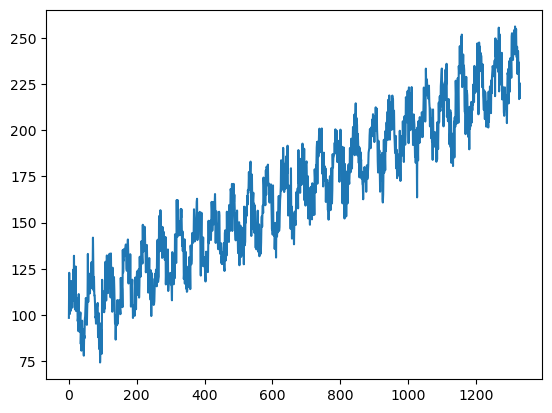

In [14]:
plt.plot(baba["Demand"]) ###this is the actual demand of the dataset.

In [15]:
baba["Date"] = pd.to_datetime(baba["Date"],dayfirst=True)
baba= baba.sort_values("Date")
baba.set_index("Date",inplace=True)

baba.head(15)
### Converting Date Column into a datetime and set as index.

,Week,Demand
Date,,
2001-01-01,1,98.42
2001-01-08,2,122.81
2001-01-15,3,100.69
2001-01-22,4,100.54
2001-01-29,5,114.69
2001-02-05,6,105.05
2001-02-12,7,102.32
2001-02-19,8,118.37
2001-02-26,9,112.79


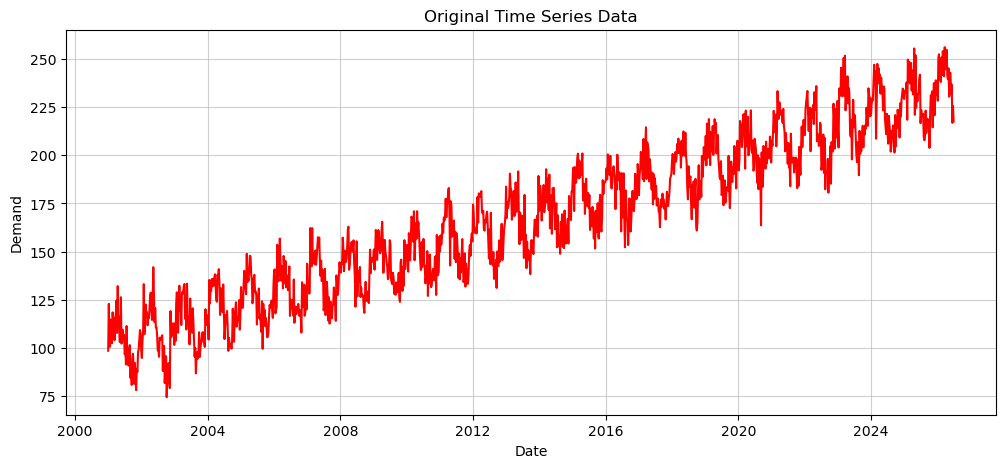

In [16]:
plt.figure(figsize=(12,5))
plt.plot(baba.index,baba['Demand'], label='Original Data', color='red')
plt.title('Original Time Series Data')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.grid(alpha=0.6)
plt.show()
### This is the initial actaul or original visualization of Sales Demand 

In [17]:
# 20-period rolling mean (assuming your data is weekly frequency)
baba['SMA_20'] = baba['Demand'].rolling(window=20).mean()


# View last few rows to confirm SMA is calculated
baba[["Demand","SMA_20"]].tail(10)
### building the 20 week SMA model

,Demand,SMA_20
Date,,
2026-04-27,239.49,243.7890
2026-05-04,245.21,244.0995
2026-05-11,230.47,244.0455
2026-05-18,242.50,244.3405
2026-05-25,242.87,245.0640
2026-06-01,231.70,244.1075
2026-06-08,236.73,243.3180
2026-06-15,216.87,242.0945
2026-06-22,225.64,241.4265


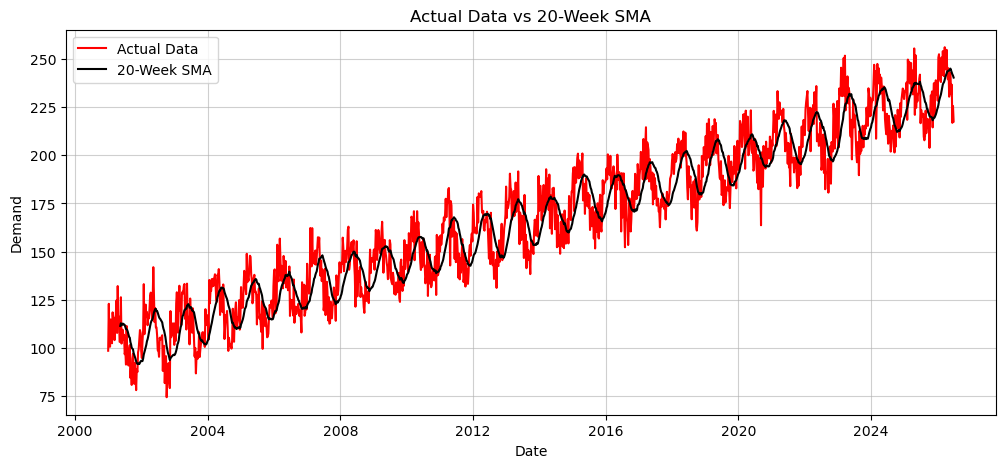

In [18]:
# Visualize actual data vs the fitted SMA
plt.figure(figsize=(12, 5))
plt.plot(baba.index, baba['Demand'], label='Actual Data', color='red')
plt.plot(baba.index, baba['SMA_20'], label='20-Week SMA', color='black')
plt.title('Actual Data vs 20-Week SMA')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(alpha=0.6)
plt.show()

In [19]:
forecast_horizon= 26
history =list(baba["Demand"].values[-20:])
forecast_values= []

for _ in range(forecast_horizon):
    next_val = np.mean(history[-20:])
    forecast_values.append(next_val)
    history.append(next_val)

last_date=baba.index[-1]
forecast_dates= pd.date_range(start=last_date,periods=forecast_horizon +1,freq='W')[1:]

forecast_baba= pd.DataFrame({"Forecast": forecast_values}, index= forecast_dates)
forecast_baba.head(15)

,Forecast
2026-07-12,240.402000
2026-07-19,239.879600
2026-07-26,239.787580
2026-08-02,239.070459
2026-08-09,238.737982
2026-08-16,238.618881
2026-08-23,237.740825
2026-08-30,237.390366
2026-09-06,236.872885
2026-09-13,235.975029


In [20]:
forecast_baba.tail(15)

,Forecast
2026-09-27,235.486644
2026-10-04,235.000477
2026-10-11,235.227000
2026-10-18,234.863350
2026-10-25,234.463018
2026-11-01,234.601169
2026-11-08,234.494727
2026-11-15,235.375964
2026-11-22,235.862762
2026-11-29,236.776400


In [21]:
# Drop rows where SMA is NaN (first 19 weeks)
eval_baba = baba.dropna(subset=['SMA_20'])

actual = eval_baba['Demand']
predicted = eval_baba['SMA_20']

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100
r2_score = r2_score(actual,predicted)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"r2_score : {r2_score:.4f}")

MAE  : 10.94
RMSE : 13.04
MAPE : 6.94%
r2_score : 0.8967


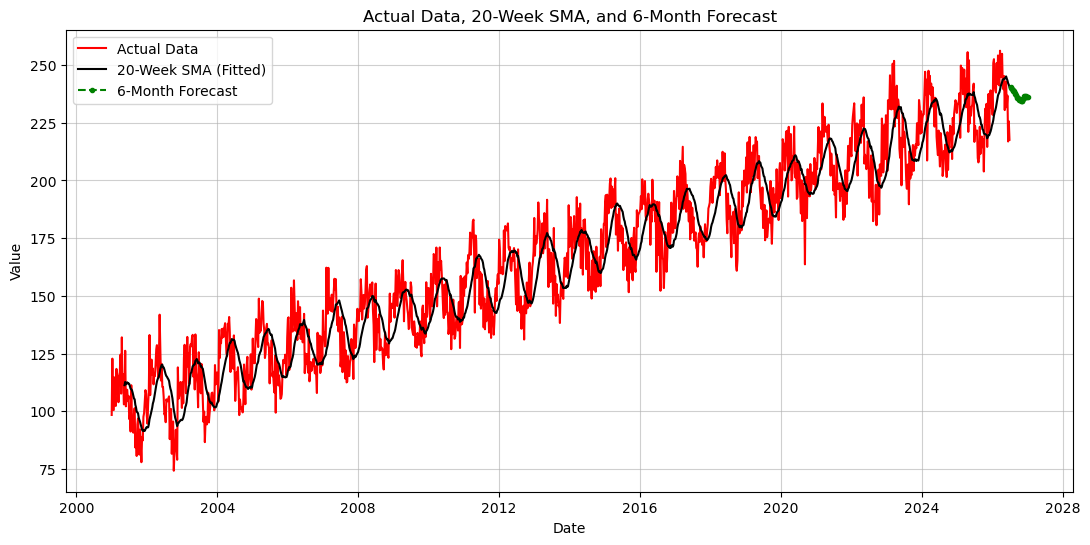

In [22]:
plt.figure(figsize=(13, 6))

plt.plot(baba.index, baba['Demand'], label='Actual Data', color='red')
plt.plot(baba.index, baba['SMA_20'], label='20-Week SMA (Fitted)', color='black')
plt.plot(forecast_baba.index, forecast_baba['Forecast'], label='6-Month Forecast',
         color='green', linestyle='--', marker='o', markersize=3)

plt.title('Actual Data, 20-Week SMA, and 6-Month Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.6)
plt.show()

In [23]:
baba[['Demand','SMA_20']].head(20)

,Demand,SMA_20
Date,,
2001-01-01,98.42,NaN
2001-01-08,122.81,NaN
2001-01-15,100.69,NaN
2001-01-22,100.54,NaN
2001-01-29,114.69,NaN
2001-02-05,105.05,NaN
2001-02-12,102.32,NaN
2001-02-19,118.37,NaN
2001-02-26,112.79,NaN
